In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/nfs/home/svu/e1498138/localgit/FEWNEW/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 10
T = 3/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 5 #scale by 2-3x
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
print(f'SNR (time-max): {data_snr:.4f}')


def log_density(params):
    params = np.asarray(params)
    log_likes = np.zeros(params.shape[0])
    for i in range(params.shape[0]):
        logm1, logm2, a, p0, e0 = params[i]
        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
    return log_likes


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u

Using dt=10s, T=0.25yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
SNR (time-max): 1539.1741


In [5]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris2_noise/int_3mth_noise_1'


In [6]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [7]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [8]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.73491335,  0.1084497 ,  0.51770635,  0.8404672 ,  0.97054957],
        [ 0.72477944,  0.11791063,  0.06560368,  1.17358462,  0.56942849],
        [ 0.77950358, -0.44375019,  0.39042193,  0.36484171,  0.91245971],
        ...,
        [ 0.97228362,  0.0321204 ,  0.87954079,  0.03474845,  0.94324324],
        [ 0.96119578,  0.04468076,  0.84679021,  0.08975181,  0.93604422],
        [ 0.97415976,  0.03080545,  0.88464947,  0.01242381,  0.9430859 ]],
       shape=(100000, 5))]

In [9]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([ 18.36575629,         -inf,         -inf, ...,         -inf,
                -inf, 344.20497947], shape=(100000,))]

In [10]:
sampler.now_covariances

[array([[ 6.06765680e-05, -7.10419309e-05,  1.79840772e-04,
         -3.02802939e-04,  4.33587198e-05],
        [-7.10419309e-05,  8.35660459e-05, -2.10998325e-04,
          3.55232029e-04, -5.13890481e-05],
        [ 1.79840772e-04, -2.10998325e-04,  5.33626242e-04,
         -8.98383713e-04,  1.29209425e-04],
        [-3.02802939e-04,  3.55232029e-04, -8.98383713e-04,
          1.51255052e-03, -2.17506207e-04],
        [ 4.33587198e-05, -5.13890481e-05,  1.29209425e-04,
         -2.17506207e-04,  3.20469436e-05]])]

In [11]:
np.argmax(logden_list)

np.int64(82387)

In [12]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.38245675, 0.81251852, 0.91879477, 8.01578958, 0.48437954]])

In [13]:
log_density(maxld_pt1)

array([5.93317671])

In [14]:
log_density([param_true])

array([4.75962607])

In [15]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [16]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[np.float64(6.0), np.float64(1.0), 0.7, 9, 0.4]

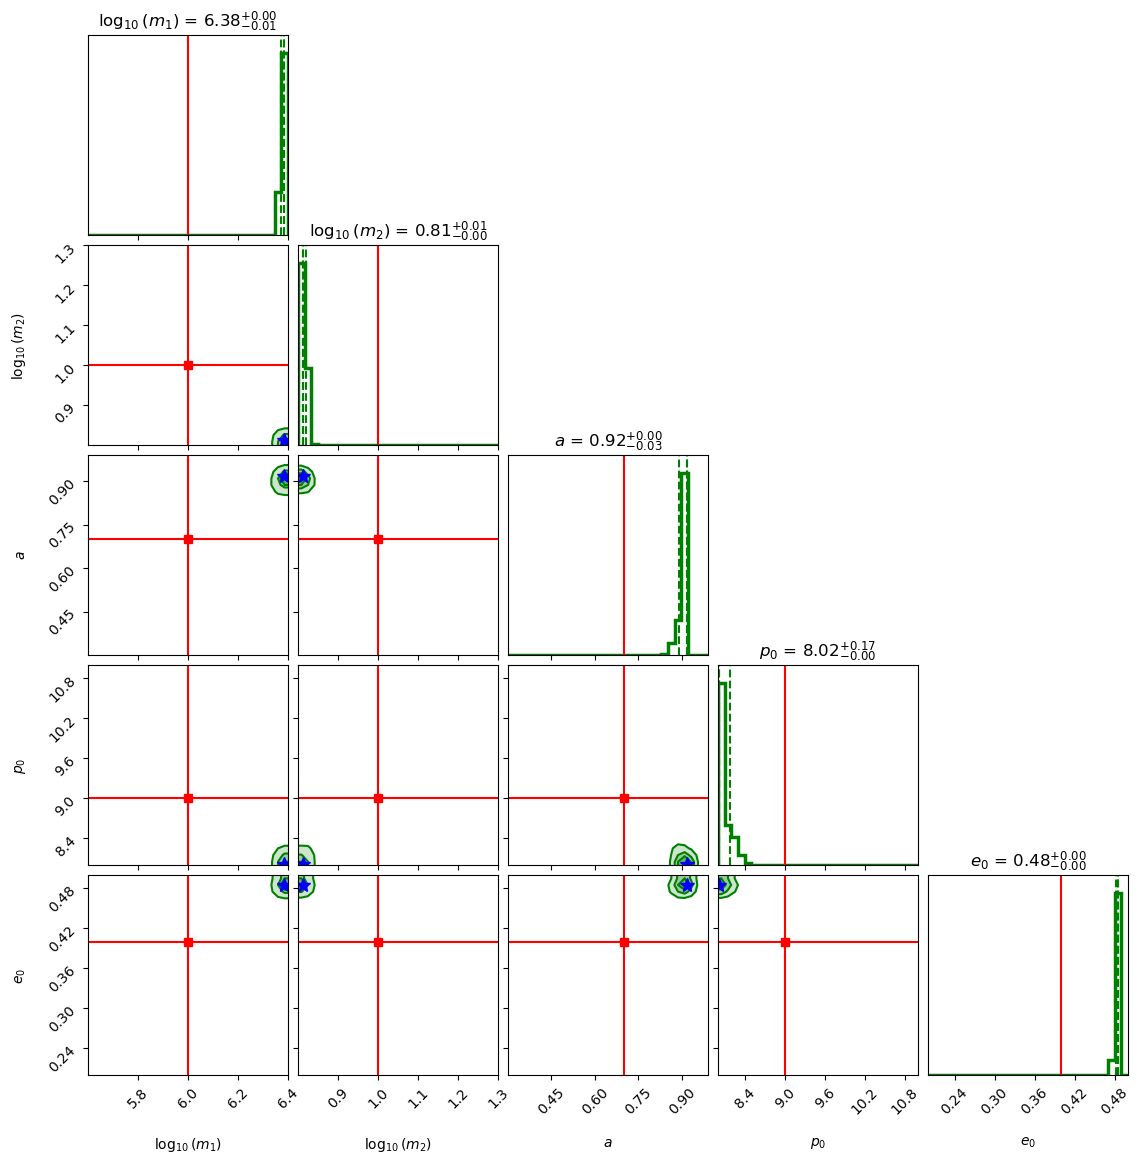

In [17]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




# connection plot

In [18]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[6.38245675, 0.81251852, 0.91879477, 8.01578958, 0.48437954]])

In [19]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [20]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [21]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [22]:
logden_theory_proc1

array([5.93317671, 2.57231843, 1.59474963, 1.11426487, 1.18466743,
       0.75153177, 0.34387702, 0.58025434, 0.34154547, 0.47304078,
       0.28267838, 0.28400002, 0.3558269 , 0.21381764, 0.16127666,
       0.54606612, 0.17382308, 0.33486019, 0.55021664, 0.23624246,
       0.40235192, 0.52952781, 0.48752327, 0.57930683, 0.4011084 ,
       0.6492645 , 0.74394758, 0.52078746, 0.46348805, 1.061822  ,
       0.81230738, 1.16302599, 0.79670272, 1.43064584, 1.4704998 ,
       1.41761564, 1.84884187, 1.73065022, 1.53919864, 1.61530683,
       1.97900746, 1.86506287, 1.74858518, 2.22568614, 2.12165228,
       2.41556288, 2.44877843, 2.48052054, 2.24156869, 4.75962607])

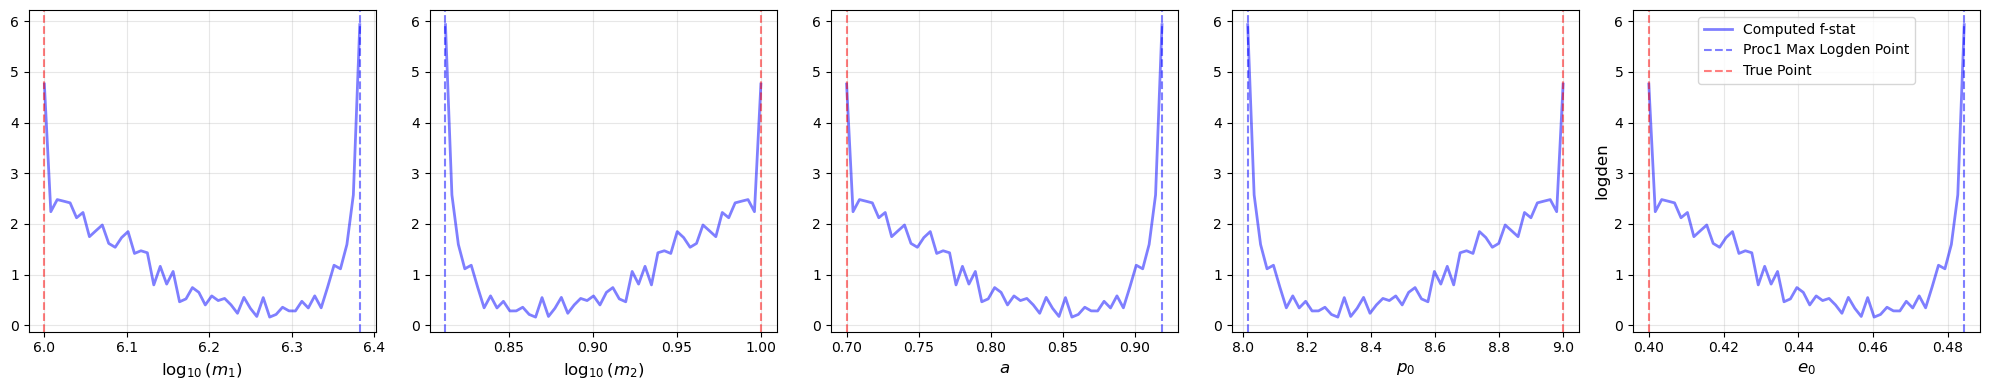

In [23]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
